# Compile experiment results into a dictionary

In [1]:
import sys
import os
import pickle
sys.path.append("../../")

metadata_dir = r"C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\data\experiment_context_sizes\metadata"
tabpfn_preds_dir = r"C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\data\experiment_context_sizes\tabpfn_preds_full"


In [2]:
def fetch_save_dict(metadata_dir):

    experiment_results_dict = {}

    for fname in os.listdir(metadata_dir):
        if not fname.endswith('.pkl'):
            continue
        fpath = os.path.join(metadata_dir, fname)
        with open(fpath, 'rb') as f:
            results_dict = pickle.load(f)

        model_name   = results_dict['model_name']
        scenario     = results_dict['scenario']
        context_size = results_dict['context_size']
        fold         = results_dict['fold']
        seed_context = results_dict['seed_context']

        experiment_results_dict \
            .setdefault(model_name, {}) \
            .setdefault(scenario, {}) \
            .setdefault(context_size, {}) \
            .setdefault(fold, {})[seed_context] = results_dict



    save_path = os.path.join(metadata_dir, "experiment_results_dict.pkl")
    with open(save_path, 'wb') as f:
        pickle.dump(experiment_results_dict, f)
    print(f"Saved to {save_path}")

In [3]:
load_path = os.path.join(metadata_dir, "experiment_results_dict.pkl")
with open(load_path, 'rb') as f:
    experiment_results_dict = pickle.load(f)
print("Loaded successfully.")
print("Models:", list(experiment_results_dict.keys()))

Loaded successfully.
Models: ['distnet', 'tabpfn']


# Helpers

In [4]:
import numpy as np
from sklearn.model_selection import KFold

from helper.tabpfn_vs_distnet_helpers import data_source_release, load_data

RANDOM_STATE=0

def load_y_test(scenario_name, fold_idx):
    sc_dict = data_source_release.get_sc_dict()
    data_dir = data_source_release.get_data_dir()

    runtimes, _, _ = load_data.get_data(
        scenario=scenario_name, 
        data_dir=data_dir,
        sc_dict=sc_dict,
        retrieve=sc_dict[scenario_name]['use']
    )
        
    runtimes = np.asarray(runtimes)

    # Get CV splits
    kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    splits = list(kf.split(np.arange(runtimes.shape[0])))
    _, test_idx = splits[fold_idx]  # process the specified fold

    #------------------------------------#
    y_test = runtimes[test_idx]
    return y_test

def load_tabpfn_preds(scenario_name, fold_idx, context_size, context_seed, seed_features, seed_samples_per_instance, feature_drop_rate, target_scale, subsample_method, num_samples_per_instance, use_cpu):
    fname = (
        f"tabpfn_{scenario_name}_{fold_idx}_{context_seed}_{seed_features}_{seed_samples_per_instance}_{feature_drop_rate}_"
                         f"{context_size}_{target_scale}_{subsample_method}_{num_samples_per_instance}_{'cpu' if use_cpu else 'gpu'}_test_preds.pkl"
    )
    fpath = os.path.join(tabpfn_preds_dir, fname)
    with open(fpath, 'rb') as f:
        preds = pickle.load(f)
    return preds
    

# Calculate metrics of interest and store results

In [5]:
SCENARIOS = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno",
]

FOLDS = range(10)

CONTEXT_SIZES = [2**i for i in range(5,14)]
CONTEXT_SIZES.extend([2**13 + 2000, 2**13 + 4000])

CONTEXT_SEEDS = [100, 200, 300, 400, 500]

MODELS = list(experiment_results_dict.keys())

N_GRID_POINTS = 15000

In [6]:
from helper.pfn_helpers import calculate_all_distribution_metrics_tabpfn_logspace
from helper.tabpfn_vs_distnet_helpers.distnet_helpers import calculate_all_distribution_metrics_distnet_logspace


tabpfn_context_size_results = []
distnet_context_size_results = []

total_experiments = len(SCENARIOS) * len(MODELS) * len(CONTEXT_SIZES) * len(FOLDS) * len(CONTEXT_SEEDS)
current_experiment = 0

for scenario in SCENARIOS:
    for model_name in MODELS:
        for context_size in CONTEXT_SIZES:
            for fold in FOLDS:
                y_test = load_y_test(scenario, fold)
                for context_seed in CONTEXT_SEEDS:
                    case_dict = experiment_results_dict[model_name][scenario][context_size][fold][context_seed]

                    if model_name == 'tabpfn':
                        tabpfn_preds = load_tabpfn_preds(scenario, fold, context_size, context_seed, case_dict['seed_features'],
                                                         case_dict['seed_samples_per_instance'], case_dict['feature_drop_rate'],
                                                         case_dict['target_scale'], case_dict['subsample_method'],
                                                         case_dict['num_samples_per_instance'], case_dict['use_cpu'])
                        metrics_summary, instance_summary = calculate_all_distribution_metrics_tabpfn_logspace(y_test, tabpfn_preds, case_dict['target_scale'], N_GRID_POINTS)
                        tabpfn_context_size_results.append({
                            "scenario": scenario, "model": model_name, "context_size": context_size,
                            "fold": fold, "context_seed": context_seed,
                            "metrics_summ0ary": metrics_summary, "instance_summary": instance_summary
                        })

                    elif model_name == 'distnet':
                        metrics_summary, instance_summary = calculate_all_distribution_metrics_distnet_logspace(y_test, case_dict['test_preds'], case_dict['y_scale'], N_GRID_POINTS)
                        distnet_context_size_results.append({
                            "scenario": scenario, "model": model_name, "context_size": context_size,
                            "fold": fold, "context_seed": context_seed,
                            "metrics_summary": metrics_summary, "instance_summary": instance_summary
                        })
                    
                    current_experiment += 1
                    print(f"✅Completed experiment {current_experiment}/{total_experiments}")

Train data loaded
Test data loaded
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
Imputed 149 values with median
✅Completed experiment 1/7700
✅Completed experiment 2/7700
✅Completed experiment 3/7700
✅Completed experiment 4/7700
✅Completed experiment 5/7700
Train data loaded
Test data loaded
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
Imputed 149 values with median
✅Completed experiment 6/7700
✅Completed experiment 7/7700
✅Completed experiment 8/7700
✅Completed experiment 9/7700
✅Completed experiment 10/7700
Train

In [7]:
results_dir = r"C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\results"
os.makedirs(results_dir, exist_ok=True)

tabpfn_save_path = os.path.join(results_dir, "tabpfn_context_size_results.pkl")
with open(tabpfn_save_path, 'wb') as f:
    pickle.dump(tabpfn_context_size_results, f)
print(f"Saved TabPFN results ({len(tabpfn_context_size_results)} entries) to {tabpfn_save_path}")

distnet_save_path = os.path.join(results_dir, "distnet_context_size_results.pkl")
with open(distnet_save_path, 'wb') as f:
    pickle.dump(distnet_context_size_results, f)
print(f"Saved DistNet results ({len(distnet_context_size_results)} entries) to {distnet_save_path}")

Saved TabPFN results (3850 entries) to C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\results\tabpfn_context_size_results.pkl
Saved DistNet results (3850 entries) to C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\results\distnet_context_size_results.pkl


### Visualization

In [9]:

import pickle
import numpy as np
from collections import defaultdict

results_dir = r"C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\results"

with open(f"{results_dir}/tabpfn_context_size_results.pkl", "rb") as f:
    tabpfn_results = pickle.load(f)

with open(f"{results_dir}/distnet_context_size_results.pkl", "rb") as f:
    distnet_results = pickle.load(f)

all_results = tabpfn_results + distnet_results

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# Aggregate: for each (model, scenario, context_size) concatenate all per-instance arrays
# across all folds and seeds, then compute mean and std.
agg = defaultdict(lambda: defaultdict(list))
# agg[(model, scenario, context_size)][metric] -> list of per-instance values

for entry in all_results:
    model        = entry["model"]
    scenario     = entry["scenario"]
    context_size = entry["context_size"]
    inst_summ    = entry["instance_summary"]
    key = (model, scenario, context_size)
    for metric in METRICS:
        vals = inst_summ[metric]
        # handle both torch tensors and numpy arrays
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()
        agg[key][metric].append(vals)

# Compute final mean / std per (model, scenario, context_size, metric)
plot_data = {}
for key, metric_dict in agg.items():
    plot_data[key] = {}
    for metric, arrays in metric_dict.items():
        combined = np.concatenate(arrays)
        plot_data[key][metric] = (combined.mean(), combined.std())

# Collect unique scenarios and context_sizes (sorted)
scenarios     = sorted({key[1] for key in plot_data})
context_sizes = sorted({key[2] for key in plot_data})
models        = ["tabpfn", "distnet"]

print(f"Scenarios: {scenarios}")
print(f"Context sizes: {context_sizes}")
print(f"Models: {models}")
print(f"Total aggregated entries: {len(plot_data)}")


Scenarios: ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']
Context sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 10192, 12192]
Models: ['tabpfn', 'distnet']
Total aggregated entries: 154


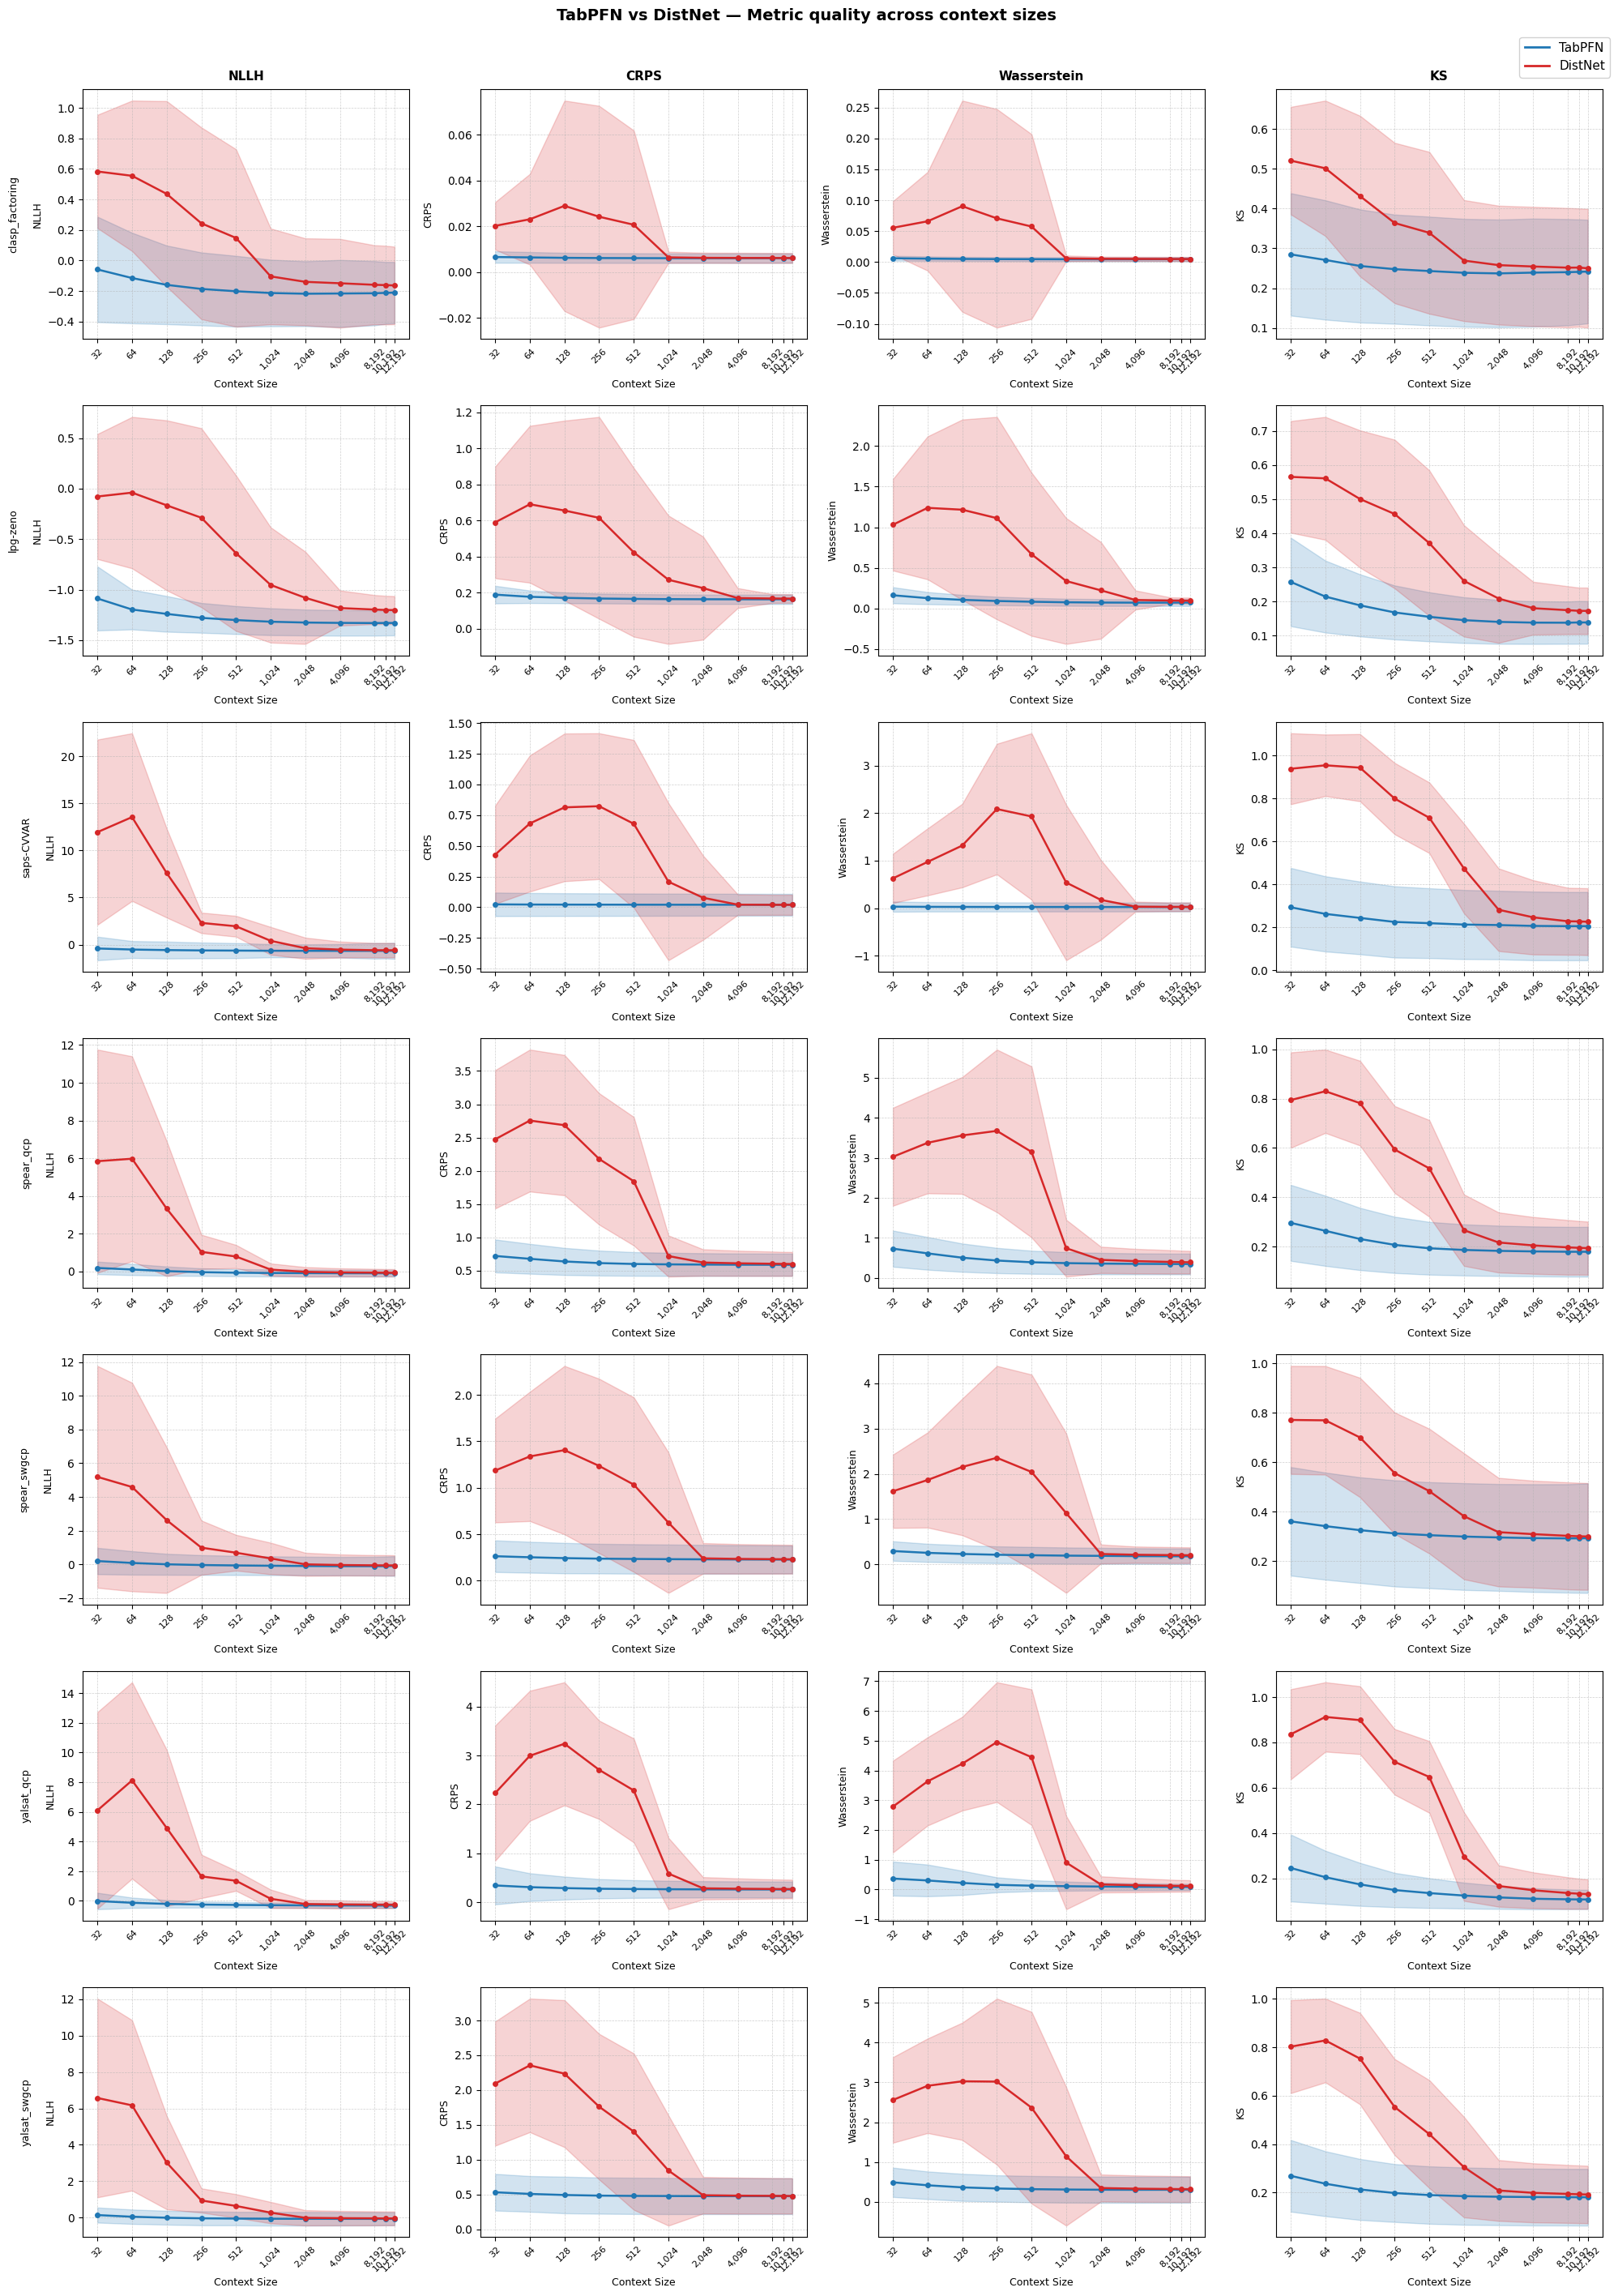

In [10]:

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

MODEL_COLORS  = {"tabpfn": "#1f77b4", "distnet": "#d62728"}
MODEL_LABELS  = {"tabpfn": "TabPFN",  "distnet": "DistNet"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}

n_rows = len(scenarios)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        for model in models:
            xs, means, stds = [], [], []
            for cs in context_sizes:
                key = (model, scenario, cs)
                if key in plot_data and metric in plot_data[key]:
                    m, s = plot_data[key][metric]
                    xs.append(cs)
                    means.append(m)
                    stds.append(s)

            if not xs:
                continue

            xs    = np.array(xs,    dtype=float)
            means = np.array(means, dtype=float)
            stds  = np.array(stds,  dtype=float)

            color = MODEL_COLORS[model]
            ax.plot(xs, means, marker="o", markersize=4, linewidth=1.8,
                    color=color, label=MODEL_LABELS[model])
            ax.fill_between(xs, means - stds, means + stds,
                            alpha=0.20, color=color)

        ax.set_xscale("log", base=2)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.set_xticks(context_sizes)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)

        ax.set_xlabel("Context Size", fontsize=9)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario}\n\n{METRIC_LABELS[metric]}",
                fontsize=9,
            )

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

# Shared legend
handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2, label=MODEL_LABELS[m])
    for m in models
]
fig.legend(handles=handles, loc="upper right", fontsize=11, framealpha=0.9,
           bbox_to_anchor=(1.0, 1.0))

plt.suptitle(
    "TabPFN vs DistNet — Metric quality across context sizes",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()


In [15]:

import pandas as pd

rows = []
for scenario in scenarios:
    for cs in context_sizes:
        row = {"Scenario": scenario, "Context Size": cs}
        for model in models:
            key = (model, scenario, cs)
            if key in plot_data:
                for metric in METRICS:
                    m, s = plot_data[key][metric]
                    row[f"{MODEL_LABELS[model]} {metric} mean"] = round(float(m), 4)
                    row[f"{MODEL_LABELS[model]} {metric} std"]  = round(float(s), 4)
            else:
                for metric in METRICS:
                    row[f"{MODEL_LABELS[model]} {metric} mean"] = None
                    row[f"{MODEL_LABELS[model]} {metric} std"]  = None
        rows.append(row)

df = pd.DataFrame(rows)

# Build a multi-level column index: (metric, model stat) for display
col_order = ["Scenario", "Context Size"]
for metric in METRICS:
    for model in models:
        col_order.append(f"{MODEL_LABELS[model]} {metric} mean")
        col_order.append(f"{MODEL_LABELS[model]} {metric} std")
df = df[col_order]

# Pretty display with multi-level header
metric_cols = {}
for metric in METRICS:
    for model in models:
        metric_cols[f"{MODEL_LABELS[model]} {metric} mean"] = (metric, MODEL_LABELS[model], "mean")
        metric_cols[f"{MODEL_LABELS[model]} {metric} std"]  = (metric, MODEL_LABELS[model], "std")

tuples = [("", "", col) if col in ("Scenario", "Context Size")
          else metric_cols[col]
          for col in df.columns]
df.columns = pd.MultiIndex.from_tuples(tuples)

pd.set_option("display.max_rows",    None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width",       None)
pd.set_option("display.float_format", "{:.4f}".format)

# Save to CSV (multi-level header flattened to "Metric_Model_stat")
csv_path = os.path.join(results_dir, "context_size_metrics_table.csv")
df_csv = df.copy()
df_csv.columns = [
    "_".join(filter(None, col)).strip("_") if isinstance(col, tuple) else col
    for col in df_csv.columns
]
df_csv.to_csv(csv_path, index=False)
print(f"Table saved to {csv_path}")

df


Table saved to C:\Users\ihagv\Desktop\Study Project UFR\Study_Project_Code\experiments\tabpfn_vs_distnet\results\context_size_metrics_table.csv


NLLH                         CRPS         \
                                  TabPFN        DistNet        TabPFN          
           Scenario Context Size    mean    std    mean    std   mean    std   
0   clasp_factoring           32 -0.0589 0.3456  0.5833 0.3713 0.0066 0.0025   
1   clasp_factoring           64 -0.1153 0.2968  0.5549 0.4931 0.0064 0.0023   
2   clasp_factoring          128 -0.1600 0.2578  0.4362 0.6085 0.0062 0.0022   
3   clasp_factoring          256 -0.1867 0.2392  0.2434 0.6286 0.0061 0.0021   
4   clasp_factoring          512 -0.2019 0.2319  0.1476 0.5815 0.0061 0.0021   
5   clasp_factoring         1024 -0.2134 0.2185 -0.1045 0.3141 0.0061 0.0021   
6   clasp_factoring         2048 -0.2181 0.2128 -0.1402 0.2851 0.0060 0.0020   
7   clasp_factoring         4096 -0.2165 0.2198 -0.1495 0.2909 0.0061 0.0021   
8   clasp_factoring         8192 -0.2150 0.2105 -0.1597 0.2591 0.0061 0.0021   
9   clasp_factoring        10192 -0.2126 0.2030 -0.1615 0.2580 0.0061 0.0021   
10  clasp_factoring        12192 -0.2109 0.2009 -0.1639 0.2543 0.0061 0.0021   
11         lpg-zeno           32 -1.0871 0.3167 -0.0780 0.6184 0.1890 0.0489   
12         lpg-zeno           64 -1.1964 0.1966 -0.0397 0.7491 0.1769 0.0346   
13         lpg-zeno          128 -1.2396 0.1766 -0.1654 0.8412 0.1711 0.0301   
14         lpg-zeno          256 -1.2789 0.1475 -0.2882 0.8859 0.1674 0.0272   
15         lpg-zeno          512 -1.3006 0.1383 -0.6385 0.7691 0.1654 0.0264   
16         lpg-zeno         1024 -1.3170 0.1332 -0.9532 0.5701 0.1640 0.0264   
17         lpg-zeno         2048 -1.3251 0.1282 -1.0804 0.4568 0.1634 0.0261   
18         lpg-zeno         4096 -1.3286 0.1266 -1.1818 0.1739 0.1631 0.0261   
19         lpg-zeno         8192 -1.3302 0.1245 -1.1967 0.1435 0.1630 0.0262   
20         lpg-zeno        10192 -1.3292 0.1239 -1.2007 0.1400 0.1632 0.0262   
21         lpg-zeno        12192 -1.3293 0.1229 -1.2017 0.1382 0.1632 0.0260   
22       saps-CVVAR           32 -0.4093 1.2537 11.9421 9.8330 0.0234 0.0960   
23       saps-CVVAR           64 -0.5194 0.8978 13.5443 8.9024 0.0220 0.0937   
24       saps-CVVAR          128 -0.5768 0.8973  7.5908 4.7189 0.0214 0.0925   
25       saps-CVVAR          256 -0.6156 0.8392  2.3075 1.0892 0.0210 0.0918   
26       saps-CVVAR          512 -0.6327 0.8002  1.9513 1.1044 0.0207 0.0910   
27       saps-CVVAR         1024 -0.6503 0.7032  0.4066 1.4703 0.0204 0.0902   
28       saps-CVVAR         2048 -0.6580 0.6866 -0.3813 1.1260 0.0203 0.0897   
29       saps-CVVAR         4096 -0.6592 0.7213 -0.5266 0.8509 0.0202 0.0892   
30       saps-CVVAR         8192 -0.6577 0.8334 -0.5902 0.7627 0.0202 0.0888   
31       saps-CVVAR        10192 -0.6578 0.8122 -0.5918 0.7792 0.0202 0.0887   
32       saps-CVVAR        12192 -0.6560 0.8572 -0.5934 0.7572 0.0202 0.0885   
33        spear_qcp           32  0.1769 0.3346  5.8397 5.9208 0.7226 0.2467   
34        spear_qcp           64  0.0948 0.2985  5.9708 5.4334 0.6795 0.2243   
35        spear_qcp          128  0.0094 0.2432  3.3183 3.5780 0.6398 0.2032   
36        spear_qcp          256 -0.0465 0.2033  1.0299 0.9089 0.6155 0.1876   
37        spear_qcp          512 -0.0752 0.1904  0.7831 0.6158 0.6021 0.1778   
38        spear_qcp         1024 -0.0896 0.1853  0.0906 0.3249 0.5962 0.1742   
39        spear_qcp         2048 -0.0968 0.1819 -0.0310 0.2524 0.5929 0.1705   
40        spear_qcp         4096 -0.1018 0.1784 -0.0577 0.2159 0.5910 0.1682   
41        spear_qcp         8192 -0.1044 0.1771 -0.0717 0.2029 0.5899 0.1673   
42        spear_qcp        10192 -0.1045 0.1771 -0.0765 0.1936 0.5898 0.1670   
43        spear_qcp        12192 -0.1044 0.1768 -0.0785 0.1940 0.5900 0.1672   
44      spear_swgcp           32  0.2004 0.7815  5.1944 6.5793 0.2640 0.1702   
45      spear_swgcp           64  0.0887 0.6967  4.5923 6.1846 0.2528 0.1663   
46      spear_swgcp          128  0.0080 0.6221  2.6247 4.3165 0.2435 0.1638   
47      spear_swgcp          256 -0.